# Feasibility geometry: $\eta_v \eta_r \eta_s r_u l \le V_{\max}$

Visual companion to *Optimization notes — Constraint geometry and enforcement*.

The optimizer's continuous decision vector includes three headroom factors
$\eta_r, \eta_s, \eta_v \in [1, 2]$. The hard hardware constraint
$\eta_v \eta_r \eta_s r_u l \le V_{\max}$ couples them. Together with the box
bounds, this defines the **feasibility region** — a 3D shape inside the
$[1,2]^3$ cube. This notebook visualizes that shape in two coordinate systems:

- **$\eta$-space.** The natural physical coordinates. The constraint surface is
  hyperbolic — $\eta_v = c/(\eta_r \eta_s)$ — curving downward at the cube
  corners.
- **$\log\eta$-space.** Taking logs turns the multiplicative constraint into an
  additive one: $\log\eta_r + \log\eta_s + \log\eta_v \le \log c$. The
  constraint surface becomes a flat plane, and the feasibility region becomes
  the half-space below it intersected with a (log-transformed) cube.

The same volume in both — but log-space makes the structure transparent.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Hardware parameters from configs/system/default.yaml
r_u = 3.0           # arrival rate (pieces/s) = 180/60
l = 0.32            # input length (m)
V_max = 3.0         # belt velocity ceiling (m/s)
budget = V_max / (r_u * l)

# Box bounds on each eta coordinate
eta_min, eta_max = 1.0, 2.0

print(f"V_max budget = V_max / (r_u * l) = {budget:.4f}")
print(f"box-corner product (max possible eta_r * eta_s * eta_v) = {eta_max**3:.4f}")
print(f"-> wall cuts into cube: {eta_max**3 > budget}")
print(f"-> wall is inside box on the eta_v axis at corner (1,1,*): "
      f"eta_v_max = {budget/(eta_min*eta_min):.3f}  (in box: {budget/(eta_min*eta_min) <= eta_max})")
print(f"-> at corner (2,2,*): eta_v_max = {budget/(eta_max*eta_max):.3f}  "
      f"(in box: {budget/(eta_max*eta_max) >= eta_min})")


V_max budget = V_max / (r_u * l) = 3.1250
box-corner product (max possible eta_r * eta_s * eta_v) = 8.0000
-> wall cuts into cube: True
-> wall is inside box on the eta_v axis at corner (1,1,*): eta_v_max = 3.125  (in box: False)
-> at corner (2,2,*): eta_v_max = 0.781  (in box: False)


In [2]:
# Helper: 12 edges of an axis-aligned cube, as (start, end) tuples
def cube_edges(lo, hi):
    corners = list(product([lo, hi], repeat=3))
    edges = []
    for i, c1 in enumerate(corners):
        for c2 in corners[i + 1:]:
            if sum(a != b for a, b in zip(c1, c2)) == 1:
                edges.append((c1, c2))
    return edges


def draw_cube(ax, lo, hi):
    for c1, c2 in cube_edges(lo, hi):
        xs, ys, zs = zip(c1, c2)
        ax.plot(xs, ys, zs, 'k-', alpha=0.7, linewidth=1.2)


## Side-by-side: $\eta$-space vs $\log\eta$-space

Green dots are feasible samples (drawn uniformly in the cube, kept if they
satisfy the constraint). The blue surface is the constraint wall — points
sitting exactly at $\eta_v \eta_r \eta_s = V_{\max}/(r_u l)$. Black lines
outline the box.

The feasible region is the volume *below* the wall and *inside* the cube.


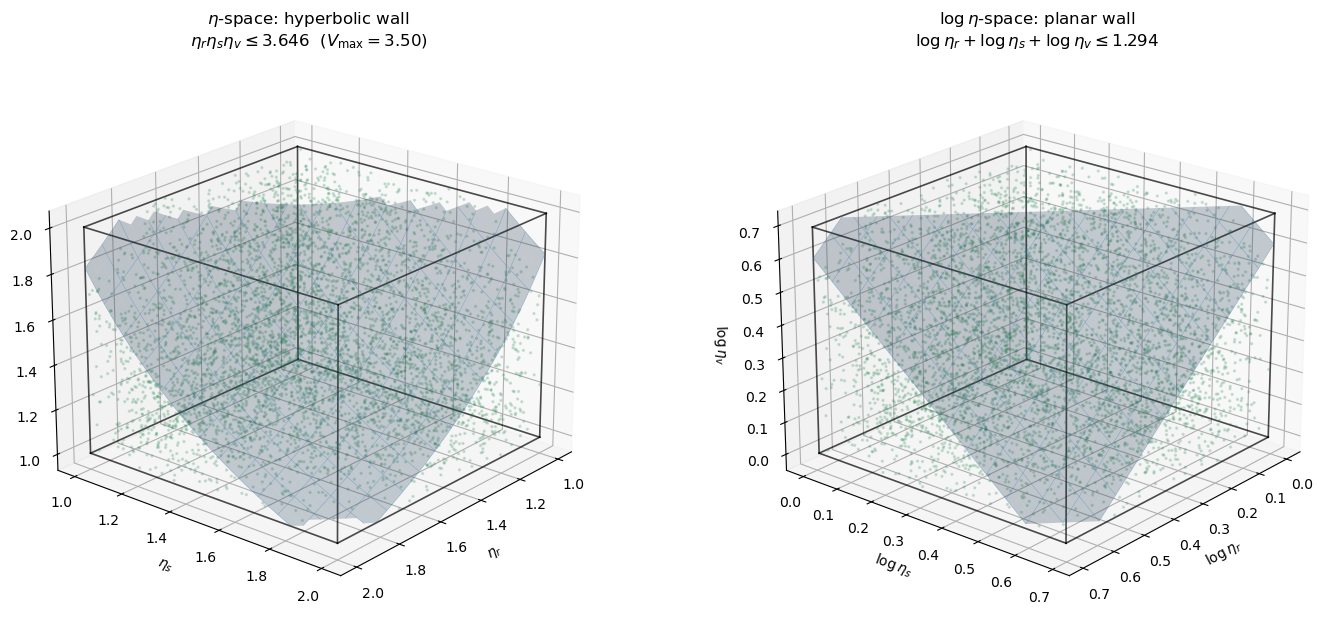

V_max = 3.50 -> feasible fraction = 63.3%


In [3]:
def plot_static(V_max_local=3.0):
    budget_local = V_max_local / (r_u * l)
    log_budget = np.log(budget_local)
    log_min, log_max = np.log(eta_min), np.log(eta_max)

    rng = np.random.default_rng(42)
    samples = rng.uniform(eta_min, eta_max, (8000, 3))
    feasible = samples[:, 0] * samples[:, 1] * samples[:, 2] <= budget_local
    fs = samples[feasible]

    fig = plt.figure(figsize=(15, 6.5))

    # --- LEFT: eta-space ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    draw_cube(ax1, eta_min, eta_max)

    n_grid = 40
    er = np.linspace(eta_min, eta_max, n_grid)
    es = np.linspace(eta_min, eta_max, n_grid)
    ER, ES = np.meshgrid(er, es)
    EV = budget_local / (ER * ES)
    EV_plot = np.where((EV >= eta_min) & (EV <= eta_max), EV, np.nan)
    ax1.plot_surface(ER, ES, EV_plot, alpha=0.25, color='steelblue', edgecolor='none')
    ax1.plot_wireframe(ER, ES, EV_plot, alpha=0.5, color='steelblue',
                       linewidth=0.4, rstride=3, cstride=3)
    ax1.scatter(fs[:, 0], fs[:, 1], fs[:, 2], c='seagreen', s=2, alpha=0.18)

    ax1.set_xlabel(r'$\eta_r$'); ax1.set_ylabel(r'$\eta_s$'); ax1.set_zlabel(r'$\eta_v$')
    ax1.set_title(r'$\eta$-space: hyperbolic wall' + '\n' +
                  rf'$\eta_r \eta_s \eta_v \leq {budget_local:.3f}$  '
                  rf'($V_{{\max}} = {V_max_local:.2f}$)')
    ax1.view_init(elev=22, azim=40)

    # --- RIGHT: log-eta-space ---
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    draw_cube(ax2, log_min, log_max)

    lr = np.linspace(log_min, log_max, n_grid)
    ls = np.linspace(log_min, log_max, n_grid)
    LR, LS = np.meshgrid(lr, ls)
    LV = log_budget - LR - LS
    LV_plot = np.where((LV >= log_min) & (LV <= log_max), LV, np.nan)
    ax2.plot_surface(LR, LS, LV_plot, alpha=0.25, color='steelblue', edgecolor='none')
    ax2.plot_wireframe(LR, LS, LV_plot, alpha=0.5, color='steelblue',
                       linewidth=0.4, rstride=3, cstride=3)
    log_fs = np.log(fs) if len(fs) else np.empty((0, 3))
    if len(log_fs):
        ax2.scatter(log_fs[:, 0], log_fs[:, 1], log_fs[:, 2],
                    c='seagreen', s=2, alpha=0.18)

    ax2.set_xlabel(r'$\log \eta_r$'); ax2.set_ylabel(r'$\log \eta_s$')
    ax2.set_zlabel(r'$\log \eta_v$')
    ax2.set_title(r'$\log\eta$-space: planar wall' + '\n' +
                  rf'$\log\eta_r + \log\eta_s + \log\eta_v \leq {log_budget:.3f}$')
    ax2.view_init(elev=22, azim=40)

    plt.tight_layout()
    plt.show()

    feas_frac = feasible.mean()
    print(f"V_max = {V_max_local:.2f} -> feasible fraction = {100*feas_frac:.1f}%")


plot_static(V_max_local=3.5)


## Why log-space matters

The constraint $\eta_v \eta_r \eta_s \le V_{\max}/(r_u l)$ is multiplicative —
each variable contributes by scaling. In $\eta$-space this gives a curved
surface (the right-hand side enters as a product). In $\log\eta$-space, the
$\log$ converts the product into a sum, and the constraint becomes
$\log\eta_v + \log\eta_r + \log\eta_s \le \log(V_{\max}/(r_u l))$ — a linear
inequality.

Linear inequalities have flat boundaries (planes / half-spaces), so the
feasibility region in $\log\eta$-space is a polyhedron with flat faces. That
matters because:

1. **Geometry is easier to reason about.** Distances, angles, and projections
   onto faces all have closed-form expressions. The cascading projection
   strategy (clip $\eta_s$ if needed, then clip $\eta_v$) is much easier to
   visualize as projection onto a plane than projection onto a hyperboloid.

2. **CMA-ES samples in transformed coordinates.** The optimizer doesn't have
   to learn the curvature of the constraint — in log-space the constraint
   surface is locally linear everywhere, so an axis-aligned Gaussian search
   distribution can fit the local geometry without needing a fancy covariance
   adaptation just to track the wall.

3. **The "tetrahedron" name earns itself.** When the wall sits inside the box
   ($V_{\max}/(r_u l) < \eta^{\max}$), the feasibility region in log-space is
   a literal tetrahedron — three orthogonal box faces plus one inclined
   constraint face. The hyperbolic wall in $\eta$-space is the same object;
   the log just removes the cosmetic curvature.


## Interactive: sweep $V_{\max}$ through the cube

Drag the slider to see the wall move. Three regimes worth noting:

- **$V_{\max}$ large** (≳ 8): wall sits outside the cube. Box dominates entirely; the entire $[1,2]^3$ is feasible. Constraint is structurally inactive.
- **$V_{\max}$ moderate** (~3-5): wall cuts through the cube. Feasible region is the cube minus a corner-region of the form $\eta_r \eta_s \eta_v > V_{\max}/(r_u l)$. *This is the regime our default config sits in (V_max = 3).*
- **$V_{\max}$ small** (≲ 2): wall has retreated far enough that the feasible region collapses toward the lower-left cube corner. At $V_{\max} = 1$ (well below the box minimum product of 1), no feasible point exists.


In [4]:
from ipywidgets import interact, FloatSlider

@interact(V_max_slider=FloatSlider(min=1.0, max=8.0, step=0.1, value=3.0,
                                   description=r'V_max', continuous_update=False))
def _plot_interactive(V_max_slider):
    plot_static(V_max_local=V_max_slider)

interactive(children=(FloatSlider(value=3.0, continuous_update=False, description='V_max', max=8.0, min=1.0), …

## What this connects to

The 10% bad-wedge calculation in *Optimization notes* — the area in the
$(\eta_r, \eta_s)$ plane where no $\eta_v \ge 1$ is feasible — is the *2D
projection* of this 3D region onto the $\eta_v = 1$ face of the cube. From
inside the cube looking down, the bad wedge is the shadow the upper part of
the wall casts on the floor.

The cascading projection acts on this geometry as follows:

1. **Step 1** projects $(\eta_r, \eta_s)$ samples onto the surface
   $\eta_r \eta_s = V_{\max}/(r_u l \cdot \eta_v^{\min})$ if they fall in the
   bad wedge. Geometrically, this slides the sample along the $\eta_s$ axis
   until it sits on the nearest feasible surface.
2. **Step 2** projects $\eta_v$ down to the wall if the sample is still above
   it. This slides the sample along the $\eta_v$ axis.

In log-space (right plot), both projections are *linear* operations onto a
*flat* plane. In $\eta$-space (left plot), they're projections onto a curved
surface. Same operation, different cosmetic complexity.
